# 垃圾郵件分類器 - 使用邏輯迴歸建立模型

本筆記本將展示如何使用邏輯迴歸（Logistic Regression）來建立一個垃圾郵件分類器。我們將完整地介紹以下步驟：

1. 資料預處理和清理
2. 特徵工程（使用 TF-IDF）
3. 模型訓練與評估
4. 視覺化分析
5. 模型保存

讓我們開始吧！

## 1. 導入所需的函式庫

首先，我們需要導入這個專案所需的所有 Python 函式庫。這包括：
- pandas: 用於資料處理
- numpy: 用於數值計算
- sklearn: 用於機器學習模型和評估
- matplotlib/seaborn: 用於資料視覺化

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_curve, precision_recall_curve, auc
)

# 設定中文字型（如果系統支援）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

## 2. 讀取和檢查數據

我們將讀取原始的 SMS 垃圾郵件數據集。這個數據集沒有標題行，第一列是標籤（spam/ham），第二列是訊息內容。
讓我們先讀取數據並進行基本的探索性分析。

In [3]:
# 讀取數據（無標題行）
df = pd.read_csv('../sms_spam_no_header.csv', header=None, names=['label', 'text'])

# 顯示基本信息
print("數據集大小:", df.shape)
print("\n前五筆數據:")
print(df.head())
print("\n標籤分佈:")
print(df['label'].value_counts())

數據集大小: (5574, 2)

前五筆數據:
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

標籤分佈:
label
ham     4827
spam     747
Name: count, dtype: int64


## 3. 資料預處理

接下來，我們將使用之前實作的預處理函數來清理文本數據。主要的處理步驟包括：
- 轉換為小寫
- 移除 URLs 和電子郵件地址
- 替換數字為 `<NUM>` 標記
- 移除標點符號
- 標準化空白字符

In [4]:
import re

def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    # 轉換為字符串並小寫
    text = str(text).lower()
    # 替換數字
    text = re.sub(r"\d+", " <NUM> ", text)
    # 移除 URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # 移除電子郵件地址
    text = re.sub(r"\S+@\S+", " ", text)
    # 移除標點符號（保留基本標記和 <NUM>）
    text = re.sub(r"[^\w\s<>]", " ", text)
    # 標準化空白
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 應用清理函數
df['text_clean'] = df['text'].apply(clean_text)

# 顯示清理前後的對比
print("清理前後的文本對比：")
for i, (orig, clean) in enumerate(zip(df['text'][:3], df['text_clean'][:3])):
    print(f"\n例子 {i+1}:")
    print(f"原始: {orig}")
    print(f"清理後: {clean}")

清理前後的文本對比：

例子 1:
原始: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
清理後: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

例子 2:
原始: Ok lar... Joking wif u oni...
清理後: ok lar joking wif u oni

例子 3:
原始: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
清理後: free entry in <NUM> a wkly comp to win fa cup final tkts <NUM> st may <NUM> text fa to <NUM> to receive entry question std txt rate t c s apply <NUM> over <NUM> s


## 4. 視覺化分析 - 類別分佈

讓我們先看看數據集中垃圾郵件（spam）和正常郵件（ham）的分佈情況。這有助於我們理解數據的不平衡性。

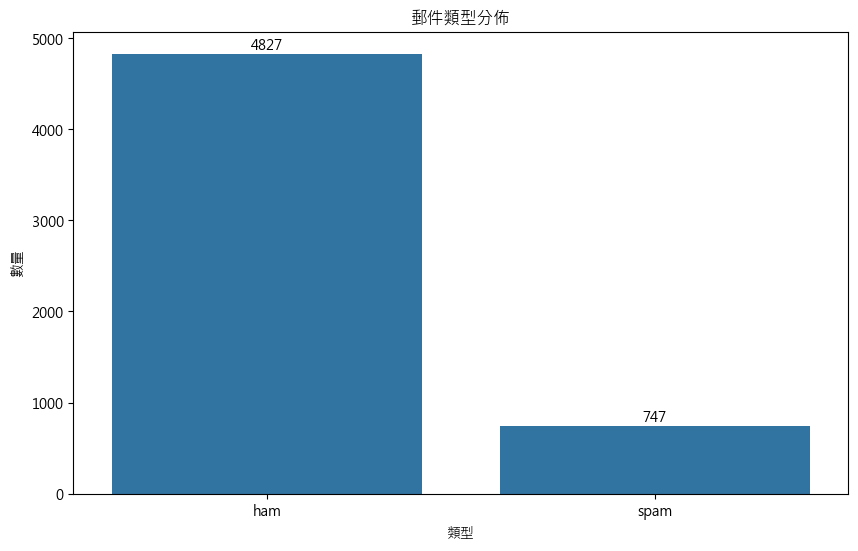


類別分佈百分比：
label
ham     86.6
spam    13.4
Name: proportion, dtype: float64


In [5]:
# 計算並顯示標籤分佈
plt.figure(figsize=(10, 6))
counts = df['label'].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.title('郵件類型分佈')
plt.xlabel('類型')
plt.ylabel('數量')
for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

# 顯示百分比
print("\n類別分佈百分比：")
print(df['label'].value_counts(normalize=True).round(4) * 100)

## 5. 分析文本長度分佈

我們來看看不同類別的郵件在文本長度上有什麼差異。這可能會是一個有用的特徵。

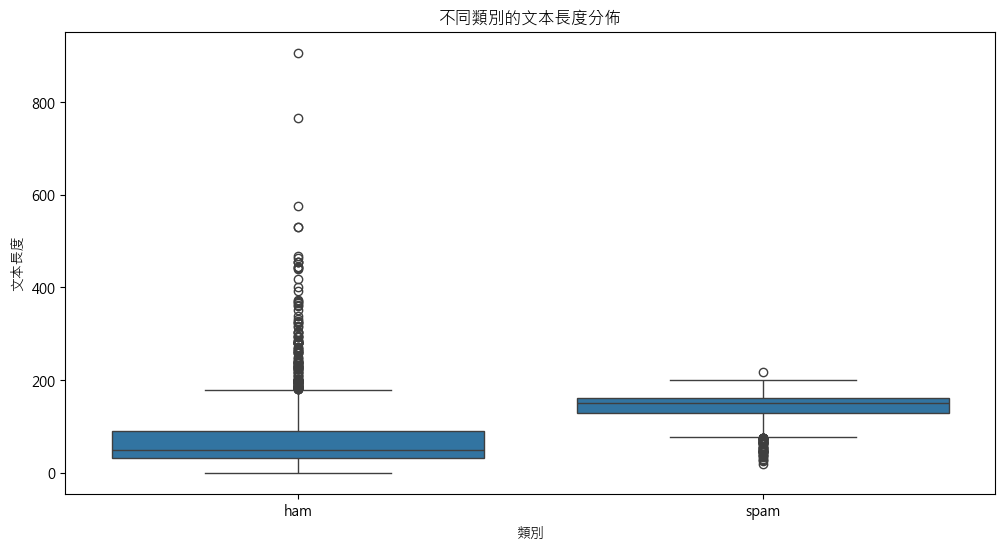


各類別文本長度統計：
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4827.0   68.901595  56.631373   0.0   32.0   50.0   91.0  907.0
spam    747.0  140.168675  32.571940  18.0  128.0  150.0  162.0  218.0


In [6]:
# 計算文本長度
df['text_length'] = df['text_clean'].str.len()

# 繪製不同類別的文本長度分佈
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='text_length', data=df)
plt.title('不同類別的文本長度分佈')
plt.xlabel('類別')
plt.ylabel('文本長度')
plt.show()

# 顯示基本統計信息
print("\n各類別文本長度統計：")
print(df.groupby('label')['text_length'].describe())

## 6. 特徵工程 - TF-IDF 轉換

現在我們將使用 TF-IDF（詞頻-逆文檔頻率）來將文本轉換為特徵向量。這是文本分類中常用的特徵提取方法。
我們將：
1. 將數據分為訓練集和測試集
2. 使用 TF-IDF 向量化器轉換文本

In [7]:
# 準備標籤
df['label_binary'] = (df['label'] == 'spam').astype(int)

# 分割數據
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'],
    df['label_binary'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_binary']
)

# TF-IDF 特徵提取
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("訓練集大小:", X_train_vec.shape)
print("測試集大小:", X_test_vec.shape)

訓練集大小: (4459, 20000)
測試集大小: (1115, 20000)


## 7. 分析高頻詞彙

讓我們看看在垃圾郵件和正常郵件中最常出現的詞彙。這可以幫助我們理解不同類型郵件的特點。

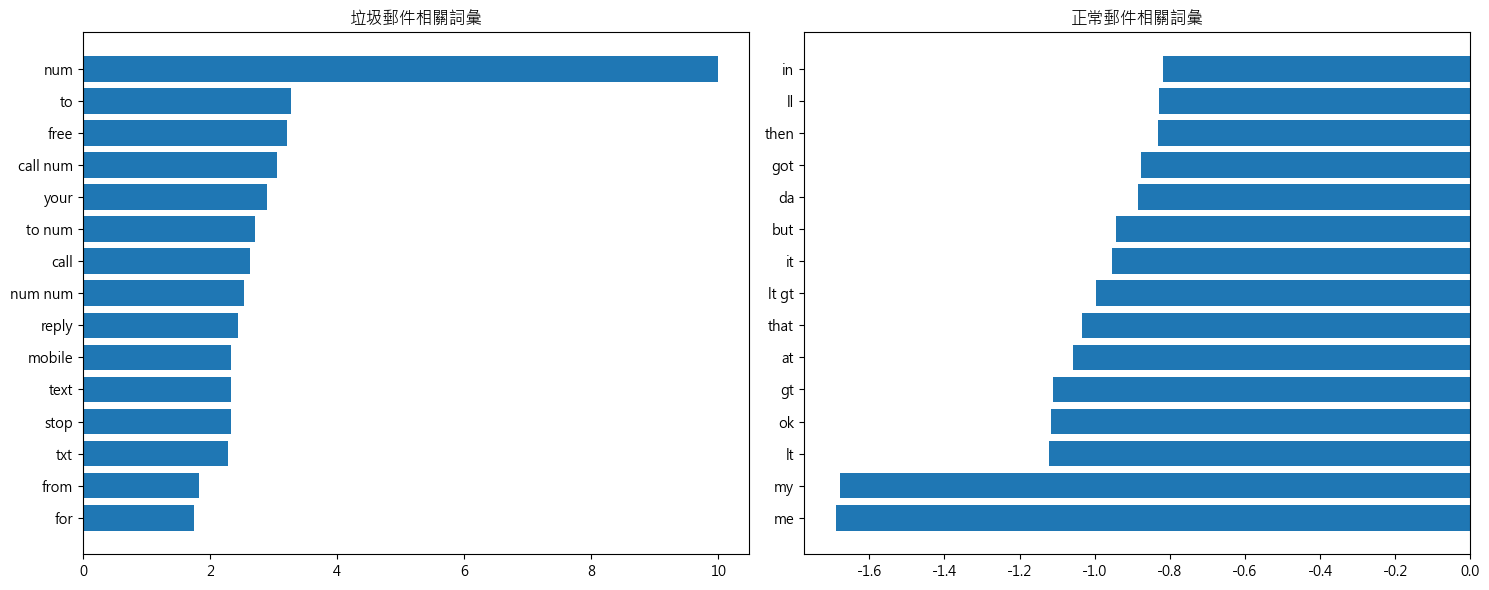

In [8]:
def plot_top_tokens(model, vectorizer, n=15):
    # 獲取特徵名稱
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    # 獲取模型係數
    coefs = model.coef_[0]
    
    # 找出最正面和最負面的係數
    top_positive_idx = np.argsort(coefs)[-n:]
    top_negative_idx = np.argsort(coefs)[:n]
    
    # 創建圖表
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 繪製垃圾郵件特徵
    ax1.barh(range(n), coefs[top_positive_idx])
    ax1.set_yticks(range(n))
    ax1.set_yticklabels(feature_names[top_positive_idx])
    ax1.set_title('垃圾郵件相關詞彙')
    
    # 繪製正常郵件特徵
    ax2.barh(range(n), coefs[top_negative_idx])
    ax2.set_yticks(range(n))
    ax2.set_yticklabels(feature_names[top_negative_idx])
    ax2.set_title('正常郵件相關詞彙')
    
    plt.tight_layout()
    plt.show()

# 訓練一個簡單的模型來獲取特徵重要性
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# 繪製高頻詞彙圖
plot_top_tokens(model, vectorizer)

## 8. 訓練邏輯迴歸模型

現在我們將使用邏輯迴歸來訓練我們的分類器。我們將：
1. 使用預設參數訓練模型
2. 在測試集上評估性能
3. 顯示詳細的評估指標

分類報告：
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.98      0.86      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



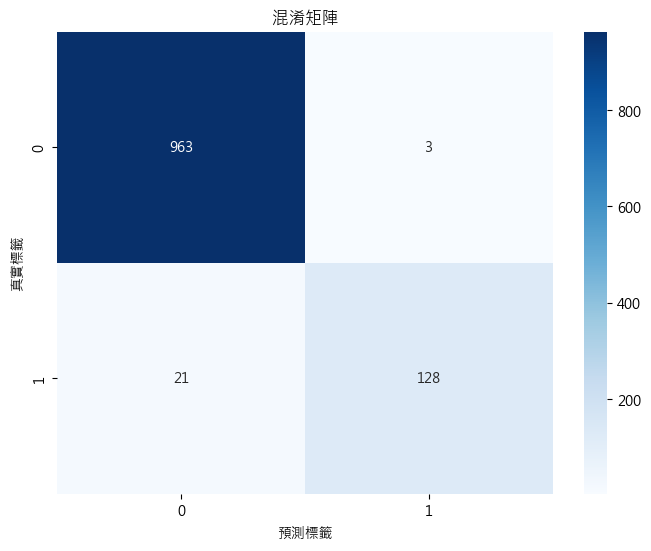

In [9]:
# 訓練模型
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

# 在測試集上進行預測
y_pred = model.predict(X_test_vec)
y_prob = model.predict_proba(X_test_vec)[:, 1]

# 顯示分類報告
print("分類報告：")
print(classification_report(y_test, y_pred))

# 繪製混淆矩陣
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('混淆矩陣')
plt.xlabel('預測標籤')
plt.ylabel('真實標籤')
plt.show()

## 9. ROC 曲線和 PR 曲線

接下來我們將繪製 ROC（受試者操作特徵）曲線和 PR（精確率-召回率）曲線，這些是評估二元分類器性能的重要指標。

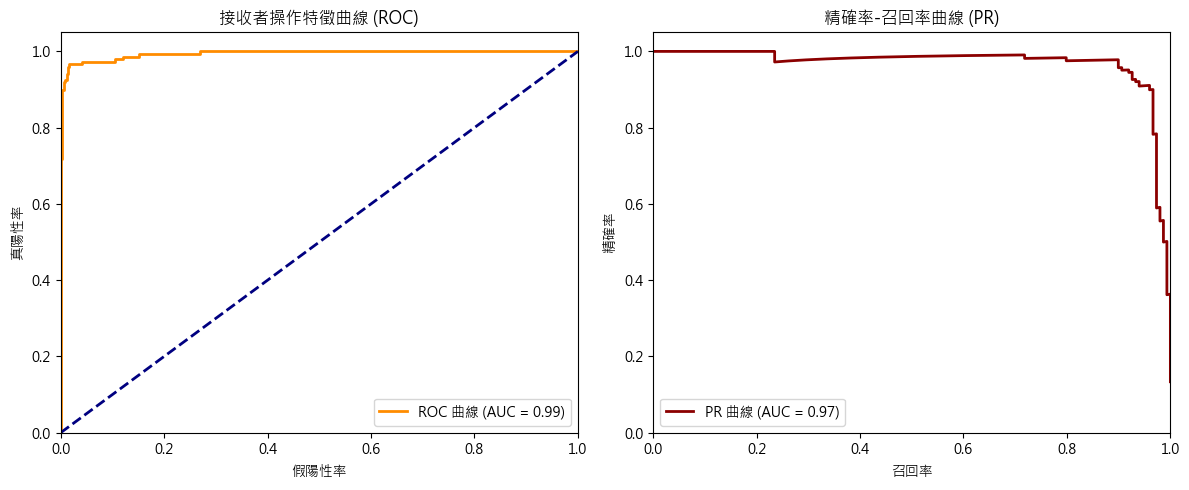

In [10]:
# 計算 ROC 曲線
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 計算 PR 曲線
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# 繪製 ROC 曲線
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC 曲線 (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假陽性率')
plt.ylabel('真陽性率')
plt.title('接收者操作特徵曲線 (ROC)')
plt.legend(loc="lower right")

# 繪製 PR 曲線
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='darkred', lw=2, label=f'PR 曲線 (AUC = {pr_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('召回率')
plt.ylabel('精確率')
plt.title('精確率-召回率曲線 (PR)')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

## 10. 決策閾值分析

最後，讓我們分析不同決策閾值對模型性能的影響。這對於在實際應用中選擇合適的閾值非常有幫助。

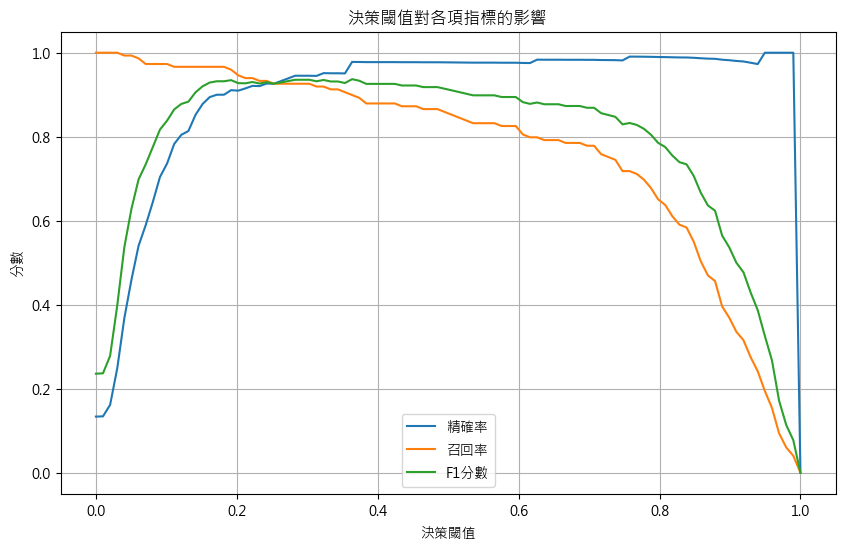


最佳 F1 分數的閾值: 0.364
在該閾值下的性能:
F1 分數: 0.937
精確率: 0.978
召回率: 0.899


In [11]:
# 計算不同閾值下的性能指標
thresholds = np.linspace(0, 1, 100)
scores = []

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    # 計算指標
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    scores.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# 轉換為 DataFrame
scores_df = pd.DataFrame(scores)

# 繪製閾值分析圖
plt.figure(figsize=(10, 6))
plt.plot(scores_df['threshold'], scores_df['precision'], label='精確率')
plt.plot(scores_df['threshold'], scores_df['recall'], label='召回率')
plt.plot(scores_df['threshold'], scores_df['f1'], label='F1分數')
plt.xlabel('決策閾值')
plt.ylabel('分數')
plt.title('決策閾值對各項指標的影響')
plt.legend()
plt.grid(True)
plt.show()

# 找出最佳 F1 分數的閾值
best_idx = scores_df['f1'].idxmax()
best_threshold = scores_df.loc[best_idx, 'threshold']
print(f"\n最佳 F1 分數的閾值: {best_threshold:.3f}")
print(f"在該閾值下的性能:")
print(f"F1 分數: {scores_df.loc[best_idx, 'f1']:.3f}")
print(f"精確率: {scores_df.loc[best_idx, 'precision']:.3f}")
print(f"召回率: {scores_df.loc[best_idx, 'recall']:.3f}")

## 11. 保存模型

最後，我們將訓練好的模型和向量器保存到檔案中，以便之後可以在其他應用程序（如 Streamlit 應用）中使用。

In [12]:
import os
import joblib

# 創建 models 目錄（如果不存在）
os.makedirs('models', exist_ok=True)

# 保存模型和向量器
joblib.dump(model, 'models/model.joblib')
joblib.dump(vectorizer, 'models/vectorizer.joblib')

print("模型和向量器已保存到 models 目錄")

模型和向量器已保存到 models 目錄


## 總結

在這個筆記本中，我們完成了以下工作：
1. 資料預處理和清理
2. 探索性數據分析和視覺化
3. 特徵工程（TF-IDF）
4. 模型訓練和評估
5. 性能視覺化（ROC、PR 曲線）
6. 閾值分析
7. 模型保存

這個模型現在可以用於 Streamlit 應用程序中，進行實時的垃圾郵件檢測。